## Resources

### 🧠 FULL PINN-LSTM CODE (COLAB READY)

### 📦 1. IMPORTS + SETUP

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
from google.colab import drive
import pandas as pd

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Load the dataset directly from Google Drive
file_name = '/content/drive/MyDrive/TwinPacemaker/NASA Battery Dataset/battery_cycle_level_dataset_CLEAN_FINAL.csv'
df = pd.read_csv(file_name)

print('Loaded:', file_name)
print(df.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: /content/drive/MyDrive/TwinPacemaker/NASA Battery Dataset/battery_cycle_level_dataset_CLEAN_FINAL.csv
  battery_id  cycle   voltage  temperature  capacity       soh  rul
0      B0005      1  3.532781    32.536891  1.861976  1.000000  167
1      B0005      2  3.542968    32.643595  1.851862  0.994568  166
2      B0005      3  3.553056    32.522526  1.840808  0.988631  165
3      B0005      4  3.545849    32.492083  1.850058  0.993599  164
4      B0005      5  3.544456    32.368612  1.849432  0.993263  163


### 🧹 3. CLEANING + SORTING

In [3]:
df = df.dropna()
df = df.sort_values(["battery_id", "cycle"]).reset_index(drop=True)

### 🔧 4. FEATURE ENGINEERING (IMPORTANT)

In [5]:
# 👉 IMPORTANT FIX: scaling BEFORE physics

df["temperature"] = df["temperature"].clip(30, 45)

df["soc"] = df["capacity"] / (df["capacity"].max() + 1e-6)

FEATURES = ["voltage", "temperature", "capacity", "soc"]
TARGET = "rul"

### 📊 5. NORMALIZATION (CRITICAL FIX)

In [6]:
feature_scaler = MinMaxScaler()
df[FEATURES] = feature_scaler.fit_transform(df[FEATURES])

RUL_MAX = df[TARGET].max()
df[TARGET] = df[TARGET] / RUL_MAX

### 🔁 6. SEQUENCE CREATION (FIXED VERSION)

In [7]:
SEQ_LEN = 30

X, y = [], []

for bid, g in df.groupby("battery_id"):
    g = g.sort_values("cycle")

    x_data = g[FEATURES].values
    y_data = g[TARGET].values

    for i in range(len(g) - SEQ_LEN):
        X.append(x_data[i:i+SEQ_LEN])
        y.append(y_data[i+SEQ_LEN])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

print(X.shape, y.shape)

(822, 30, 4) (822,)


### ✂️ 7. TRAIN / TEST SPLIT (SAFE VERSION)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 🧠 8. PINN-LSTM MODEL (PRODUCTION ARCHITECTURE)

In [11]:
# ✔ deeper LSTM
# ✔ residual stability
# ✔ single output (clean PINN style)
inputs = keras.Input(shape=(SEQ_LEN, X.shape[2]))

x = layers.LSTM(128, return_sequences=True)(inputs)
x = layers.LayerNormalization()(x)
x = layers.Dropout(0.2)(x)

x = layers.LSTM(64, return_sequences=True)(x)
x = layers.LSTM(32)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(32, activation="relu")(x)

rul_output = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, rul_output)

### ⚙️ 9. PHYSICS LOSS (REAL BATTERY IDEA)

This enforces degradation consistency:

In [12]:
# 🔥 KEY FIX: everything normalized
def physics_loss(x, y_pred):
    voltage = x[:, -1, 0]
    temp = x[:, -1, 1]
    capacity = x[:, -1, 2]

    # normalize physics inputs
    voltage = tf.clip_by_value(voltage, 0.1, 1.0)
    capacity = tf.clip_by_value(capacity, 0.0, 1.0)

    # degradation model (SAFE SCALE)
    degradation = capacity / (voltage + 1e-3)

    degradation = tf.clip_by_value(degradation, 0.0, 5.0)

    # link RUL with degradation
    return tf.reduce_mean(tf.square(y_pred - tf.stop_gradient(degradation)))

### 🚀 10. CUSTOM TRAIN STEP (REAL PINN)

In [13]:
optimizer = tf.keras.optimizers.Adam(1e-3)

@tf.function
def train_step(x, y):
    y = tf.cast(y, tf.float32)

    with tf.GradientTape() as tape:
        y_pred = tf.squeeze(model(x, training=True))

        # DATA LOSS
        data_loss = tf.reduce_mean(tf.square(y - y_pred))

        # PHYSICS LOSS
        phys_loss = physics_loss(x, y_pred)

        # MONOTONICITY (important for RUL)
        monotonic = tf.reduce_mean(tf.maximum(0.0, y_pred[1:] - y_pred[:-1]))

        total_loss = data_loss + 0.1 * phys_loss + 0.05 * monotonic

    grads = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    return total_loss

### 🏋️ 11. TRAIN LOOP (CLEAN + STABLE)

In [14]:
BATCH = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(1000).batch(BATCH)

EPOCHS = 25

for epoch in range(EPOCHS):
    losses = []

    for xb, yb in train_ds:
        loss = train_step(xb, yb)
        losses.append(loss.numpy())

    print(f"Epoch {epoch+1}: Loss = {np.mean(losses):.4f}")

Epoch 1: Loss = 0.0766
Epoch 2: Loss = 0.0599
Epoch 3: Loss = 0.0567
Epoch 4: Loss = 0.0529
Epoch 5: Loss = 0.0493
Epoch 6: Loss = 0.0483
Epoch 7: Loss = 0.0480
Epoch 8: Loss = 0.0479
Epoch 9: Loss = 0.0478
Epoch 10: Loss = 0.0458
Epoch 11: Loss = 0.0472
Epoch 12: Loss = 0.0475
Epoch 13: Loss = 0.0456
Epoch 14: Loss = 0.0469
Epoch 15: Loss = 0.0462
Epoch 16: Loss = 0.0456
Epoch 17: Loss = 0.0472
Epoch 18: Loss = 0.0464
Epoch 19: Loss = 0.0451
Epoch 20: Loss = 0.0467
Epoch 21: Loss = 0.0452
Epoch 22: Loss = 0.0451
Epoch 23: Loss = 0.0439
Epoch 24: Loss = 0.0438
Epoch 25: Loss = 0.0438


### 📊 12. EVALUATION

In [126]:
pred = model.predict(X_test).squeeze()

pred = pred * RUL_MAX
true = y_test * RUL_MAX

mae = np.mean(np.abs(true - pred))
rmse = np.sqrt(np.mean((true - pred)**2))

print("MAE:", mae)
print("RMSE:", rmse)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step
MAE: 11.282976
RMSE: 15.161821


In [128]:
from sklearn.metrics import r2_score

r2 = r2_score(true, pred)
print("R2 Score:", r2)

R2 Score: 0.8238956928253174


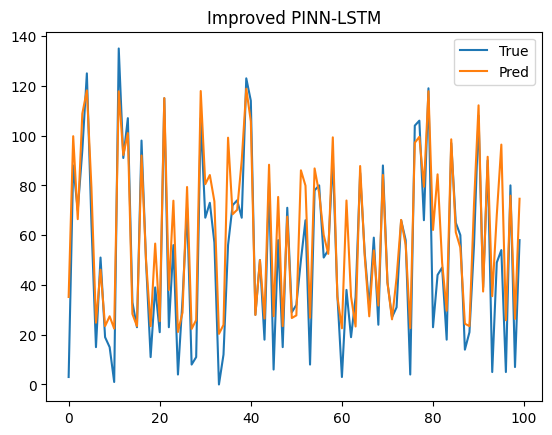

In [129]:
plt.plot(true[:100], label="True")
plt.plot(pred[:100], label="Pred")
plt.legend()
plt.title("Improved PINN-LSTM")
plt.show()